# Цель: Посмотреть как себя покажет Self-Supervision обучение

В данном проекте мы реализуем и обучим модели, основанные на контрастном обучении (InfoNCE), реализуем подходы неконтрастного обучения (NCL) и сравним их с Supervised learning.

Мы рассмотрим, как различные парадигмы обучения — контролируемое, контрастное и неконтрастное — влияют на качество усвоенных векторных представлений и стабильность процесса обучения.

## Многоформатное сопоставительное обучение аудиопредставлениям

Основная идея этого подхода заключается в обучении робастных аудиовложений путем сопоставления
различных *форматов* (или представлений) одного и того же аудиосэмпла.
Например, одна ветвь может кодировать **сырой сигнал (1D)**, а другая —
его **спектрограмму (2D)**.

Благодаря применению контрастивной потери (InfoNCE) модель обучается:
- **объединять** вложения из разных форматов одного и того же аудио;
- **раздвигать** вложения из разных аудиосэмплов.

Такая многоформатная конфигурация побуждает кодер захватывать **общее семантическое содержание**
во всех входных представлениях, что приводит к более общим и переносимым аудиопризнакам.

[paper1](https://arxiv.org/pdf/2103.06508), [paper2](https://arxiv.org/pdf/2010.09542)

[github source](https://github.com/HondamunigePrasannaSilva/CLAR?tab=readme-ov-file)

## Аудио Датасет

Набор данных с 10 произнесёнными числами несколькими дикторами
```
!git clone https://github.com/soerenab/AudioMNIST.git
```

In [1]:
# !git clone https://github.com/soerenab/AudioMNIST.git

In [2]:
# !mkdir models

In [3]:
import ast
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import torchaudio.transforms as T
import warnings

from IPython.display import Audio, clear_output
from omegaconf import DictConfig
from pathlib import Path
from sklearn.manifold import TSNE
from torch import optim
from torch.utils.data import Subset, DataLoader
from torchaudio import transforms
from tqdm.notebook import tqdm
from typing import Dict

In [4]:
warnings.filterwarnings("ignore", module="torchaudio._backend")

plt.rcParams.update({'font.size': 14})

In [5]:
seed = 12345
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True

In [6]:
def collate(batch):
    # Выравниваем данные перед подачей
    wavs, labels = zip(*batch)
    wavs = nn.utils.rnn.pad_sequence([w.squeeze(0).t() for w in wavs], batch_first=True)  # [B, Tw, 1]? we transposed; fix:
    wavs = nn.utils.rnn.pad_sequence([w.squeeze(0) for w in wavs], batch_first=True)  # [B, T]
    labels = torch.tensor(labels, dtype=torch.long)
    return wavs, labels

In [7]:
class AudioMNISTDataset(torch.utils.data.Dataset):
    # Класс обработки самих данных
    def __init__(self, root, sr=16000):
        self.root = root
        self.sr = sr
        self.items = self.list_wavs_and_labels(root)

    def __len__(self):
      return len(self.items)

    def list_wavs_and_labels(self, root: str):
      base = Path(root)
      speakers = sorted([p for p in base.iterdir() if p.is_dir()])
      items = []
      for sp in speakers:
          for wav in sorted(sp.glob("**/*.wav")):
              # файл, к примеру, "9_10_0_0_1.wav" (digit_speaker_..)
              name = wav.stem.split("_")
              digit = int(name[0])
              speaker_id = sp.name
              items.append((str(wav), digit, speaker_id))
      return items

    def load_wav(self, path):
        wav, sr = torchaudio.load(path)  # [C, T]
        if sr != self.sr:
            wav = torchaudio.functional.resample(wav, sr, self.sr)
        wav = wav.mean(dim=0, keepdim=True)  # mono [1, T]
        return wav

    def __getitem__(self, idx):
        path, label, speaker = self.items[idx]
        wav = self.load_wav(path)

        return wav, label

In [8]:
def split_indices_by_speaker(dataset: AudioMNISTDataset, valid_speakers: set, test_speakers: set):
    # Разделим данные на train, valid и test
    train_idxs = []
    valid_idxs = []
    test_idxs = []
    for idx, (_, _, spk) in enumerate(dataset.items):
        if spk in test_speakers:
            test_idxs.append(idx)
        elif spk in valid_speakers:
            valid_idxs.append(idx)
        else:
            train_idxs.append(idx)
    return train_idxs, valid_idxs, test_idxs

In [9]:
def CreateResNet1D():
    return ResNet1D(block)

In [10]:
def CreateResNet2D(img_channels=3):
    return ResNet(block_resnet2d, image_channels=img_channels)

In [11]:
def device_as(t1, t2):
   return t1.to(t2.device)

In [12]:
def pitchshift(audio, SAMPLE_RATE=16000, shift = 2):
    '''
    Сдвиг высоты тона (PS): случайным образом повышает или понижает высоту аудиосигнала.
    Основываясь на экспериментальных наблюдениях, мы определили диапазон сдвигов высоты тона, который поддерживал
    общую когерентность входного аудиосигнала, находилось в диапазоне [-15, 15] полутонов.

    Attributes:
    - :param audio: audio tensor
    - :param SAMPLE_RATE: Sample rate, default=16000
    - :param shift: Pitch shift
    - :return: describe what it returns
    '''
    assert audio != None, "audio should not be None"
    transform = transforms.PitchShift(sample_rate=SAMPLE_RATE, n_steps=shift)
    waveform_shift = transform(audio)
    return waveform_shift

In [13]:
def fade_in_out(audio):
    '''
    Плавное нарастание/затухание (FD): постепенное увеличение/уменьшение интенсивности звука в
    начале/конце аудиосигнала.
    Степень затухания можеть быть линейной, логарифмической или экспоненциальной (применяется
    с равномерной вероятностью 1/3). Величина затухания для каждой стороны
    аудиосигнала может достигать максимум половины аудиосигнала. Величина затухания
    была ещё одним случайным параметром, выбираемым для каждого сэмпла.
    '''
    assert audio != None, "audio should not be None"
    _fade_shape = ['linear', 'logarithmic', 'exponential']
    _fade_size = [i for i in range(1, int(audio.shape[2]/2))]

    transform = transforms.Fade(fade_in_len=random.choice(_fade_size), fade_out_len=random.choice(_fade_size), fade_shape=random.choice(_fade_shape))
    waveform_fade_in_out = transform(audio)
    return waveform_fade_in_out

In [14]:
def add_white_noise_(signal, noise_level):
    """
    Добавление шума: смешивание аудиосигнала со случайным белым, коричневым и розовым шумом.
    В нашей реализации интенсивность шумового сигнала выбиралась случайным образом на основе
    соотношения сигнал/шум. Белый, коричневый или розовый цвет применялись в зависимости
    от дополнительного случайного параметра, выбранного из равномерного распределения (смешанный шум).
    """
    noise = torch.randn_like(signal)*torch.std(signal) * noise_level
    noisy_signal = signal + noise
    return noisy_signal

In [15]:
def timemasking(waveform, batch_size, sample_rate=16000):
    '''
    Временное маскирование: при заданном аудиосигнале в этом преобразовании мы случайным образом выбираем небольшой
    сегмент полного сигнала и устанавливаем значения сигнала в этом сегменте равными нормальному шуму или
    постоянному значению. В нашей реализации мы не только случайно выбирали местоположение
    маскируемого сегмента, но и его размер. Размер маскируемого сегмента был установлен таким образом,
    чтобы он составлял не более 1/8 входного сигнала.
    max_mask = int(sample_rate/8)*torch.ones(size=[batch_size])
    pos_iniziale = torch.randint(low=0, high=sample_rate, size=[batch_size])
    min_mask = sample_rate-pos_iniziale
    min_elements = torch.min(min_mask,max_mask)
    pos_finale = pos_iniziale+min_elements.to(torch.int)
    indices = torch.arange(sample_rate).unsqueeze(0).expand(batch_size, -1)
    range_mask = (indices >= pos_iniziale.unsqueeze(1)) & (indices <= pos_finale.unsqueeze(1))
    range_mask = range_mask[:,None,:]
    signal_[range_mask] = 0

    return signal_
    '''
    
    bs, ch, length = waveform.shape
    mask_len = length // 8
    augmented = waveform.clone()
    for i in range(bs):
        start = random.randint(0, length - mask_len)
        augmented[i, :, start:start + mask_len] = 0.0
    return augmented

In [16]:
def timeStretching():
    """
    замедляет или ускоряет аудиосэмпл (сохраняя высоту звука неизменной).
    В этом подходе мы преобразовываем сигнал, сначала вычисляя STFT сигнала, растягивая его
    с помощью фазового вокодера и вычисляя обратное STFT для восстановления сигнала во временной области.
    После этих преобразований мы понижаем дискретизацию или обрезаем сигнал, чтобы он соответствовал количеству
    сэмплов входного сигнала. Если скорость растяжения была больше 1, сигнал
    ускоряется. В противном случае, если скорость растяжения была меньше 1, сигнал замедляется.
    Скорость растяжения во времени рандомизируется для каждого аудиосигнала со значениями в диапазоне [0,5, 1,5].
    Но, здесь мы не будем акцентировать на этом внимание.
    """
    return

In [17]:
def create(config):
    '''
    Не будем плодить лишнего и сделаем конфиг для наших исследований
    '''
    # Поднимем модель, на основе класса модели
    model = Net(img_channels=config.IMG_CHANNEL, num_classes = config.CLASSES, mode = config.MODE).to(device)

    if config.LOSE == 'ContrastiveLoss':
        # Задаем loss
        loss = ContrastiveLoss()
    
        # Задаем Melspectogram и STFT (Амплитуду и фазу)
        mel_transform = LogMelSpectrogram(
            sample_rate=16000,
            n_fft=2048,
            hop_length=128,
            n_mels=128,
            f_min=40,
            f_max=8000,
            mel_scale="slaney"
        ).to(device)
    
        # Зададим наш оптимизатор
        optimizer = optim.Adam(model.parameters(), lr=config.LR, betas=(config.B1, config.B2), weight_decay=config.WEIGHT_DECAY)
        
        return model, loss, optimizer, mel_transform
        
    elif config.LOSE == 'CrossEntropyLoss':
        # Создаем классификационную голову (Evaluation Head)
        eval_head = EvaluationHead(num_classes=config.CLASSES).to(device)
        # Зададим CrossEntropyLoss loss
        loss = nn.CrossEntropyLoss()

        
        # Задаем Melspectogram и STFT (Амплитуду и фазу)
        mel_transform = LogMelSpectrogram(
            sample_rate=16000,
            n_fft=2048,
            hop_length=128,
            n_mels=128,
            f_min=40,
            f_max=8000,
            mel_scale="slaney"
        ).to(device)
    
        # Зададим наш оптимизатор
        parameters = list(model.parameters()) + list(eval_head.parameters())
        optimizer = optim.Adam(model.parameters(), lr=config.LR, betas=(config.B1, config.B2), weight_decay=config.WEIGHT_DECAY)
        
        return model, eval_head, loss, optimizer, mel_transform

    elif config.LOSE == 'VicReg':
        # Укажем на VICRegLoss
        loss = VICRegLoss()
    
        # Задаем Melspectogram и STFT (Амплитуду и фазу)
        mel_transform = LogMelSpectrogram(
            sample_rate=16000,
            n_fft=2048,
            hop_length=128,
            n_mels=128,
            f_min=40,
            f_max=8000,
            mel_scale="slaney"
        ).to(device)
    
        # Зададим наш оптимизатор
        optimizer = optim.Adam(model.parameters(), lr=config.LR, betas=(config.B1, config.B2), weight_decay=config.WEIGHT_DECAY)
        
        return model, loss, optimizer, mel_transform

In [18]:
def train(model, eval_head, closs, optimizer, trainloader, valloader, testloader, config, mel_transform, stft_trasform):
    '''
    Обучение
    '''

    model.train()
    eval_head.train()
    all_accuracy_valid = []
    all_accuracy_test = []
    all_losses = []
    scaler = torch.amp.GradScaler()

    for epoch in range(config.EPOCHS):
        progress_bar = tqdm(total=len(trainloader), unit='step')
        losses = []
        clos_ = []
        for audio, lab in trainloader:
            optimizer.zero_grad()

            audio = audio.to(device)

            # Получаем augmentation и spectograms!
            spectograms, audios = createModelInput(audio, mel_transform, None, augmentation=True)

            with torch.amp.autocast(device_type=str(device)):
                
                if config.LOSE == 'ContrastiveLoss':
                    audio_emb, spect_emb, _, _ = model(spectograms, audios)
                    loss = closs(audio_emb, spect_emb)
                    
                elif config.LOSE == 'CrossEntropyLoss':
                    
                    if config.MODE == 'All':
                        audio_emb, spect_emb, _, _ = model(spectograms, audios)
                        # Соединяем эмбеддинги
                        combined_embedding = torch.cat([audio_emb, spect_emb], dim=-1)
                        # Проходим через классификационную голову
                        logits = eval_head(combined_embedding)
                        
                    elif config.MODE == 'audio':
                        audio_emb, audio = model(spectograms, audios)
                        logits_input = torch.cat([audio_emb, audio_emb], dim=-1)
                        logits = eval_head(logits_input)
                        
                    elif config.MODE == 'spectrograms':
                        spect_emb, spect = model(spectograms, audios)
                        logits_input = torch.cat([spect_emb, spect_emb], dim=-1)
                        logits = eval_head(logits_input)
                        
                    loss = closs(logits, lab.to(device))

                elif config.LOSE == 'VicReg':
                    audio_emb, spect_emb, _, _ = model(spectograms, audios)
                    loss_metrics = closs(audio_emb, spect_emb)
                    loss = loss_metrics['loss']
                    
                clos_.append(loss.item())


            # Считаем loss и backward
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            #progress bar stuff
            progress_bar.set_description(f"Epoch {epoch+1}/{config.EPOCHS}")
            progress_bar.set_postfix(loss=loss.item())  # Update the loss value
            progress_bar.update(1)

            # save loss to statistics
            losses.append(loss.item())

        # end for batch

        if epoch%3==0:
            # EVALUATION HEAD
            torch.save(model.state_dict(), f"models/model_{config.MODEL_TITLE}.pt")
            accuracy_valid, accuracy_test = evaluationphase(model, eval_head, valloader, testloader, config, mel_transform, stft_trasform)

        accuracy_valid, accuracy_test = evaluationphase(model, eval_head, valloader, testloader, config, mel_transform, stft_trasform)
        all_accuracy_valid.append(accuracy_valid)

        # Т.к. я ленивый, то решил и на тесте проверить сразу
        all_accuracy_test.append(accuracy_test)
        all_losses.append(np.mean(losses))

    return all_losses, all_accuracy_valid, all_accuracy_test

In [19]:
def createModelInput(audio, mel_transform, stft_trasform, augmentation=True):

    audio = audio.unsqueeze(1)

    # CALCUALTE AUGMENTATION 1 AND AUGMENTATION 2
    if augmentation == True:
        audio = fade_in_out(audio)
        audio = timemasking(audio,audio.shape[0])

    # Create the augmented spectograms size [BATCH_SIZE, 3, 200, 200]
    #spectograms = createSpectograms(audio, stft_trasform, mel_transform)
    spectograms = mel_transform(audio)
    spectograms = spectograms.to(device)

    return  spectograms, audio

In [20]:
def evaluationphase(model, eval_head, val_loader, test_loader, config, mel_transform, stft_trasform):

    model.eval()
    # Get dataloaders
    # Freeze the gradients for model1
    for param in model.parameters():
        param.requires_grad = False

    

    def train_head(model, trainloader):

        # Create model
        modelEvaluation = None
        modelEvaluation = EvaluationHead(num_classes = config.CLASSES).to(device)

        # Define the optimizer, the paper use
        optimizer = optim.Adam(modelEvaluation.parameters(), lr=config.LR)

        criterion = torch.nn.CrossEntropyLoss()

        for epoch in range(config.EVAL_EPOCHS):
            progress_bar = tqdm(total=len(trainloader), unit='step', leave=False)
            losses = []
            for audio,labels in trainloader:
                optimizer.zero_grad()
                audio = audio.to(device)
                # Create augmentation and spectograms!
                spectograms,audios = createModelInput(audio, mel_transform, stft_trasform, augmentation=False)

                labels = labels.to(device)

                # Use frozen encoder
                with torch.no_grad():
                    audio_emb, spect_emb, _, _ = model(spectograms, audios)

                inputs = torch.cat([audio_emb, spect_emb], dim = -1)
                outputs = modelEvaluation(inputs)
                loss = criterion(outputs, labels)

                # Calculate loss and backward
                loss.backward()
                optimizer.step()

                losses.append(loss.item())

                #progress bar stuff
                progress_bar.set_description(f"Head tuning epoch {epoch+1}/{config.EVAL_EPOCHS}")
                progress_bar.set_postfix(loss=np.mean(losses))  # Update the loss value
                progress_bar.update(1)

            # end for batch


        return modelEvaluation

    def evaluation(model, model_eval, dataloader):
        model_eval.eval()
        progress_bar = tqdm(total=len(dataloader), unit='step')
        total = 0
        correct = 0
        with torch.no_grad():
            for i, (audio,labels) in enumerate(dataloader):

                audio = audio.to(device)
                spectograms, audios = createModelInput(audio, mel_transform, stft_trasform,  augmentation=False)
                
                if config.LOSE == 'ContrastiveLoss' or config.LOSE == 'VicReg':
                    # Use frozen encoder
                    audio_emb, spect_emb, _, _ = model(spectograms, audios)
                    inputs = torch.cat([audio_emb, spect_emb], dim = -1)
                    labels = labels.to(device)
                    outputs = model_eval(inputs)
                    _, predicated = torch.max(outputs.data, 1)
                    total += labels.size(0)
    
                    correct += (predicated == labels).sum().item()
                    
                elif config.LOSE == 'CrossEntropyLoss':
                    
                    if config.MODE == 'All':
                        audio_emb, spect_emb, _, _ = model(spectograms, audios)
                        labels = labels.to(device)
                        # Соединяем эмбеддинги
                        labels_input = torch.cat([audio_emb, spect_emb], dim=-1)
                        
                    elif config.MODE == 'audio':
                        audio_emb, audio = model(spectograms, audios)
                        labels_input = torch.cat([audio_emb, audio_emb], dim=-1)
                        labels = labels.to(labels_input)
                        
                    elif config.MODE == 'spectrograms':
                        spect_emb, spect = model(spectograms, audios)
                        labels_input = torch.cat([spect_emb, spect_emb], dim=-1)
                        labels = labels.to(device)
                        
                        # Соединяем эмбеддинги
                    logits = model_eval(labels_input)
                    _, predicted = torch.max(logits.data, 1)
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()

                
                #progress bar stuff
                progress_bar.set_description(f"Evaluation {i+1}/{len(dataloader)}")
                progress_bar.update(1)

            # end for batch

        return correct/total


    if config.LOSE == 'ContrastiveLoss' or config.LOSE == 'VicReg':
        eval_head = train_head(model, train_loader)
    elif config.LOSE == 'CrossEntropyLoss':
        pass
    accuracy_valid = evaluation(model, eval_head, val_loader)
    print(f"Accuracy on validation: {accuracy_valid}")
    accuracy_test = evaluation(model, eval_head, test_loader)
    model.train()
    eval_head.train()
    for param in model.parameters():
        param.requires_grad = True

    return accuracy_valid, accuracy_test

In [21]:
def plot_metrics(losses, accuracies):
    """
    Plot training and validation metrics
    """
    epochs = range(1, len(losses) + 1)

    # Create subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot loss
    ax1.plot(epochs, losses, 'b-', label='Loss', linewidth=2)
    ax1.set_title('Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot accuracy
    ax2.plot(epochs, accuracies, 'b-', label='Accuracy', linewidth=2)
    ax2.set_title('Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Adjust layout and display
    plt.tight_layout()
    plt.show()

In [22]:
class LogMelSpectrogram(T.MelSpectrogram):
    def __init__(self, eps=1e-8, **kwargs):
        super().__init__(**kwargs)
        self.eps = eps

    def forward(self, waveform):
        return (super().forward(waveform) + self.eps).log()

In [23]:
class block(nn.Module):
    def __init__(self, in_channels, out_channels, identity_downsample=None,stride=1):
        super(block, self).__init__()

        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=1, padding=0)
        self.bn1 = nn.BatchNorm1d(out_channels)

        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn2 = nn.BatchNorm1d(out_channels)

        self.identity_downsample = identity_downsample
        self.relu = nn.ReLU()


    def forward(self, x):
        identity = x

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)

        if self.identity_downsample is not None:
            identity = self.identity_downsample(identity)

        x += identity
        x = self.relu(x)

        return x

In [24]:
class ResNet1D(nn.Module):
    # Resnet 18 [2, 2, 2, 2]
    def __init__(self, block):
        super(ResNet1D, self).__init__()
        # for resnet18
        layers = [2, 2, 2, 2]
        self.expansion = 1

        self.in_channels = 64
        self.conv1 = nn.Conv1d(1, self.in_channels, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm1d(self.in_channels)
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool1d(kernel_size=3, stride=2, padding=1)


        self.layer1 = self._make_layer(block, layers[0], 64, stride=1)
        self.layer2 = self._make_layer(block, layers[1], 128, stride=2)
        self.layer3 = self._make_layer(block, layers[2], 256, stride=2)
        self.layer4 = self._make_layer(block, layers[3], 512, stride=2)

        self.avgpool = nn.AdaptiveAvgPool1d(output_size=1)


        # size after avgpool = [32, 512, 1]

    def forward(self,x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)

        #x = x.reshape(x.shape[0], -1)
        #x = self.fc(x)

        return x



    def _make_layer(self, block, num_residual_block, out_channels, stride):
        identity_downsample = None
        layers = []

        if stride != 1:
            identity_downsample = nn.Sequential(nn.Conv1d(self.in_channels,
                                                out_channels*self.expansion,
                                                kernel_size=1,
                                                stride=stride,
                                                bias=False),
                                                nn.BatchNorm1d(out_channels*self.expansion),
                                                )
        layers.append(
            block(self.in_channels,out_channels, identity_downsample, stride)
        )
        self.in_channels = out_channels * self.expansion

        for i in range(1, num_residual_block):
            layers.append(block(self.in_channels,out_channels ))

        return nn.Sequential(*layers)

In [25]:
class block_resnet2d(nn.Module):
    def __init__(self, in_channels, out_channels, identity_downsample=None,stride=1):
        super(block_resnet2d, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, padding=0)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.identity_downsample = identity_downsample
        self.relu = nn.ReLU()


    def forward(self, x):
        identity = x

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)

        if self.identity_downsample is not None:
            identity = self.identity_downsample(identity)

        x += identity
        x = self.relu(x)

        return x

In [26]:
class ResNet(nn.Module):
    # Resnet 18 [2, 2, 2, 2]
    def __init__(self, block, image_channels):
        super(ResNet, self).__init__()
        # for resnet18
        layers = [2, 2, 2, 2]
        self.expansion = 1

        self.in_channels = 64
        self.conv1 = nn.Conv2d(image_channels, self.in_channels, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(self.in_channels)
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)


        self.layer1 = self._make_layer(block, layers[0], 64, stride=1)
        self.layer2 = self._make_layer(block, layers[1], 128, stride=2)
        self.layer3 = self._make_layer(block, layers[2], 256, stride=2)
        self.layer4 = self._make_layer(block, layers[3], 512, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1,1))


    def forward(self,x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)

        return x



    def _make_layer(self, block, num_residual_block, out_channels, stride):
        identity_downsample = None
        layers = []

        if stride != 1:
            identity_downsample = nn.Sequential(nn.Conv2d(self.in_channels,
                                                out_channels*self.expansion,
                                                kernel_size=1,
                                                stride=stride,
                                                bias=False),
                                                nn.BatchNorm2d(out_channels*self.expansion),
                                                )
        layers.append(
            block(self.in_channels,out_channels, identity_downsample, stride)
        )
        self.in_channels = out_channels * self.expansion

        for i in range(1, num_residual_block):
            layers.append(block(self.in_channels,out_channels ))

        return nn.Sequential(*layers)

In [27]:
class Net(nn.Module):

    def __init__(self, img_channels = 1, num_classes = 35, mode = 'All'):
        super(Net, self).__init__()
        self.mode = mode
        ####################### ENCODER ###################################
        if self.mode == 'All':
            self.resnet_1D = CreateResNet1D()
            self.resnet_2D = CreateResNet2D(img_channels=img_channels)
        elif self.mode == 'audio':
            self.resnet_1D = CreateResNet1D()
        elif self.mode == 'spectrograms':
            self.resnet_2D = CreateResNet2D(img_channels=img_channels)

        self.output = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 128)
        )

        ####################################################################

    def forward(self, input_spectogram, input_audio):
        """
            resnet2d and resnet1d output is [BS, 512, 1, 1]
            Output:
                - audio_emb, specs_emb used for contrastive loss
                - audio, spectograms used for Evaluation layer
                - output used for semi supervised - cross entropy
        """

        if self.mode == 'All':
            audio = self.resnet_1D(input_audio)
            audio = audio.squeeze()
            spectograms = self.resnet_2D(input_spectogram)
            spectograms = spectograms.squeeze()

            audio_emb = self.output(audio)
            specs_emb = self.output(spectograms)

            return audio_emb, specs_emb, audio, spectograms
            
        elif self.mode == 'audio':
            audio = self.resnet_1D(input_audio)
            audio = audio.squeeze()

            audio_emb = self.output(audio)

            return audio_emb, audio
            
        elif self.mode == 'spectrograms':
            spectograms = self.resnet_2D(input_spectogram)
            spectograms = spectograms.squeeze()

            specs_emb = self.output(spectograms)

            return specs_emb, spectograms

In [28]:
class EvaluationHead(nn.Module):
    """
    Linear classifier head
    """
    def __init__(self, num_classes = 35):
        super(EvaluationHead, self).__init__()

        self.evaluation = nn.Sequential(
                    nn.Linear(256,num_classes)
        )

    def forward(self,x):
        x = self.evaluation(x)
        return x

In [29]:
class ContrastiveLoss(nn.Module):
  def __init__(self, temperature=0.5):
    super().__init__()
    self.temperature = temperature

  def calc_similarity_batch(self, a, b):
    rep = torch.cat([a,b])
    return F.cosine_similarity(rep.unsqueeze(1), rep.unsqueeze(0), dim=2)

  def forward(self, proj_1, proj_2):
    batch_size = proj_1.shape[0]
    z_i = F.normalize(proj_1, p=2, dim=1)
    z_j = F.normalize(proj_2, p=2, dim=1)

    similarity_matrix = self.calc_similarity_batch(z_i, z_j)

    #######
    #aa#ab#
    #######
    #ba#bb#
    #######

    sim_ij = torch.diag(similarity_matrix, batch_size)
    sim_ji = torch.diag(similarity_matrix, -batch_size)

    positives = torch.cat([sim_ij, sim_ji])

    nominator = torch.exp(positives / self.temperature)

    mask = (~torch.eye(batch_size*2, batch_size*2).bool()).float()
    mask = device_as(mask, similarity_matrix)

    denominator = mask * torch.exp(similarity_matrix / self.temperature)
    all_losses = -torch.log(nominator / torch.sum(denominator))
    loss = torch.sum(all_losses) / (2*batch_size)

    return loss

In [30]:
class VICRegLoss(nn.Module):
    def __init__(
        self,
        inv_coeff: float = 25.0,
        var_coeff: float = 15.0,
        cov_coeff: float = 1.0,
        gamma: float = 1.0,
    ):
        super().__init__()
        self.inv_coeff = inv_coeff
        self.var_coeff = var_coeff
        self.cov_coeff = cov_coeff
        self.gamma = gamma

    def forward(self, x: torch.Tensor, y: torch.Tensor) -> Dict[str, torch.Tensor]:
        """Computes the VICReg loss.

        ---
        Args:
            x: Features map.
                Shape of [batch_size, representation_size].
            y: Features map.
                Shape of [batch_size, representation_size].

        ---
        Returns:
            The VICReg loss.
                Dictionary where values are of shape of [1,].
        """
        metrics = dict()
        metrics["inv-loss"] = self.inv_coeff * self.representation_loss(x, y)
        metrics["var-loss"] = (
            self.var_coeff
            * (self.variance_loss(x, self.gamma) + self.variance_loss(y, self.gamma))
            / 2
        )
        metrics["cov-loss"] = (
            self.cov_coeff * (self.covariance_loss(x) + self.covariance_loss(y)) / 2
        )
        metrics["loss"] = sum(metrics.values())
        return metrics

    @staticmethod
    def representation_loss(x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        """Computes the representation loss.
        Force the representations of the same object to be similar.

        ---
        Args:
            x: Features map.
                Shape of [batch_size, representation_size].
            y: Features map.
                Shape of [batch_size, representation_size].

        ---
        Returns:
            The representation loss.
                Shape of [1,].
        """
        return F.mse_loss(x, y)

    @staticmethod
    def variance_loss(x: torch.Tensor, gamma: float) -> torch.Tensor:
        """Computes the variance loss.
        Push the representations across the batch
        to be different between each other.
        Avoid the model to collapse to a single point.

        The gamma parameter is used as a threshold so that
        the model is no longer penalized if its std is above
        that threshold.

        ---
        Args:
            x: Features map.
                Shape of [batch_size, representation_size].

        ---
        Returns:
            The variance loss.
                Shape of [1,].
        """
        x = x - x.mean(dim=0)
        std = x.std(dim=0)
        var_loss = F.relu(gamma - std).mean()
        return var_loss

    @staticmethod
    def covariance_loss(x: torch.Tensor) -> torch.Tensor:
        """Computes the covariance loss.
        Decorrelates the embeddings' dimensions, which pushes
        the model to capture more information per dimension.

        ---
        Args:
            x: Features map.
                Shape of [batch_size, representation_size].

        ---
        Returns:
            The covariance loss.
                Shape of [1,].
        """
        x = x - x.mean(dim=0)
        cov = (x.T @ x) / (x.shape[0] - 1)
        cov_loss = cov.fill_diagonal_(0.0).pow(2).sum() / x.shape[1]
        return cov_loss

In [31]:
#check for cuda
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Available device:", device)

Available device: cuda


In [32]:
root = 'AudioMNIST/data'

In [33]:
# Ensure data loading correctly
_test_dataset = AudioMNISTDataset(root)
_test_dataset[0]

(tensor([[0.0003, 0.0005, 0.0004,  ..., 0.0005, 0.0005, 0.0006]]), 0)

In [34]:
# Split dataset by speakers
NUM_TEST_SPEAKERS = 6
full_ds = AudioMNISTDataset(root=root)
all_speakers = sorted({spk for (_, _, spk) in full_ds.items})
valid_speakers = set(all_speakers[-NUM_TEST_SPEAKERS*2:-NUM_TEST_SPEAKERS])
test_speakers = set(all_speakers[-NUM_TEST_SPEAKERS:])
train_idxs, valid_idxs, test_idxs = split_indices_by_speaker(full_ds, valid_speakers, test_speakers)

train_ds = Subset(full_ds, train_idxs)
valid_ds = Subset(full_ds, valid_idxs)
test_ds = Subset(full_ds, test_idxs)

## Проба пера

Обучим на основе сигналов, спектрограмм и сигналов и спектрограмм вместе. Это шаг с supervised и вычислим точность.

### Ок, попробуем просто с волной звука

In [35]:
hyperparameters = {
        'LR': 3e-4,
        'WEIGHT_DECAY': 1e-6,
        'B1':0.9,
        'B2':0.999,
        'EPOCHS': 10,
        'BATCH_SIZE': 128,
        'IMG_CHANNEL': 1,
        'CLASSES': 10,
        'EVAL_BATCH':128,
        'EVAL_EPOCHS':1,
        'MODEL_TITLE': 'supervised_audio',
        'MODE': 'audio',
        'LOSE': 'CrossEntropyLoss'
}
config = DictConfig(hyperparameters)

# Init dataloaders
train_loader = DataLoader(train_ds, batch_size=config.BATCH_SIZE, shuffle=True, collate_fn=collate)
val_loader  = DataLoader(valid_ds,  batch_size=config.EVAL_BATCH, shuffle=False, collate_fn=collate)
test_loader  = DataLoader(test_ds,  batch_size=config.EVAL_BATCH, shuffle=False, collate_fn=collate)

#make the model, data and optimization problem
model, eval_head, loss, optimizer, mel_transform = create(config)

#train the model
losses, accuracy_valid, accuracy_test = train(
    model,
    eval_head,
    loss,
    optimizer,
    train_loader,
    val_loader,
    test_loader,
    config,
    mel_transform, None
)

  0%|          | 0/188 [00:00<?, ?step/s]

  0%|          | 0/24 [00:00<?, ?step/s]

Accuracy on validation: 0.8676666666666667


  0%|          | 0/24 [00:00<?, ?step/s]

  0%|          | 0/24 [00:00<?, ?step/s]

...

Accuracy on validation: 0.8903333333333333


  0%|          | 0/24 [00:00<?, ?step/s]

  0%|          | 0/24 [00:00<?, ?step/s]

Accuracy on validation: 0.8903333333333333


  0%|          | 0/24 [00:00<?, ?step/s]

In [36]:
final_metrics = pd.DataFrame(
    {
        'Method': 'supervised_audio',
        'accuracy_valid': [accuracy_valid],
        'accuracy_test': [accuracy_test]
    }
)

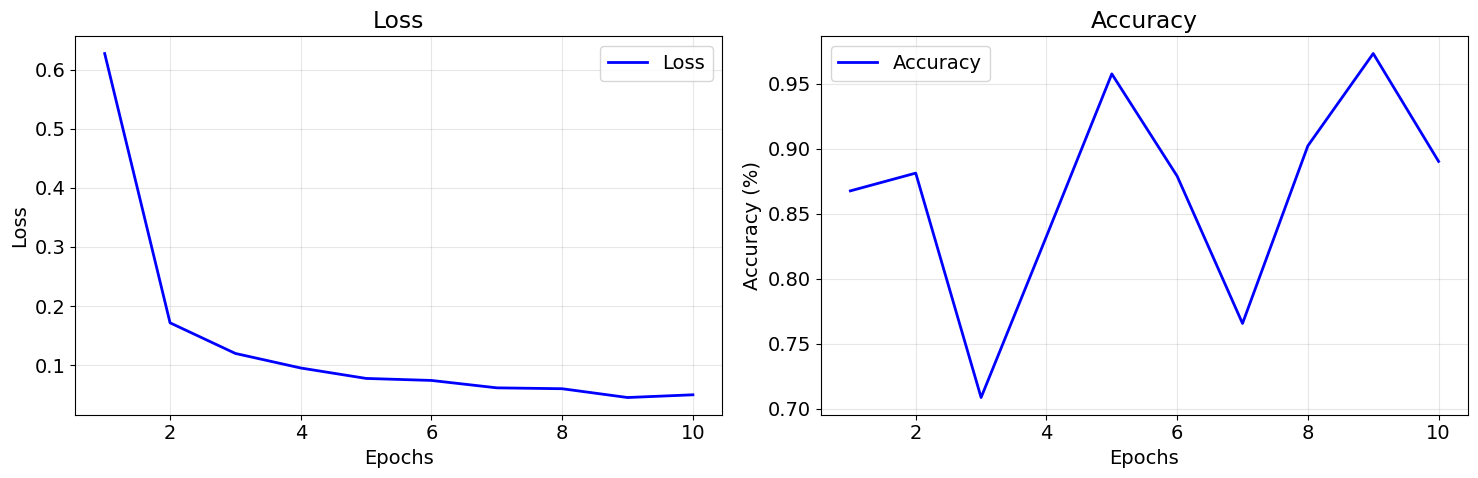

In [37]:
plot_metrics(losses, accuracy_valid)
clear_output(wait=True)

### А теперь попробуем со спектрограммой

In [38]:
hyperparameters['MODEL_TITLE'] = 'supervised_spectrograms'
hyperparameters['MODE'] = 'spectrograms'

config = DictConfig(hyperparameters)

#make the model, data and optimization problem
model, eval_head, loss, optimizer, mel_transform = create(config)

#train the model
losses, accuracy_valid, accuracy_test = train(
    model,
    eval_head,
    loss,
    optimizer,
    train_loader,
    val_loader,
    test_loader,
    config,
    mel_transform, None
)

  0%|          | 0/188 [00:00<?, ?step/s]

  0%|          | 0/24 [00:00<?, ?step/s]

Accuracy on validation: 0.983


  0%|          | 0/24 [00:00<?, ?step/s]

  0%|          | 0/24 [00:00<?, ?step/s]

...

Accuracy on validation: 0.9526666666666667


  0%|          | 0/24 [00:00<?, ?step/s]

  0%|          | 0/24 [00:00<?, ?step/s]

Accuracy on validation: 0.9526666666666667


  0%|          | 0/24 [00:00<?, ?step/s]

In [39]:
new_row = {'Method': 'supervised_spectrograms', 'accuracy_valid': accuracy_valid, 'accuracy_test': accuracy_test}
final_metrics.loc[len(final_metrics)] = new_row

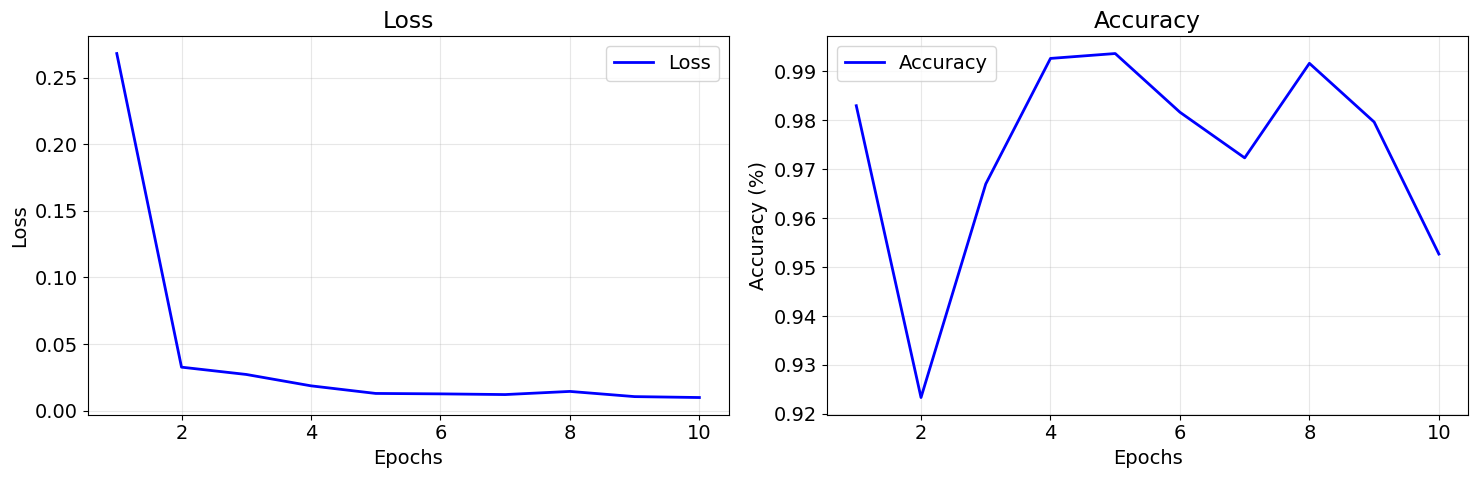

In [40]:
plot_metrics(losses, accuracy_valid)
clear_output(wait=True)

### А теперь с обоими

In [41]:
hyperparameters['MODEL_TITLE'] = 'supervised_all'
hyperparameters['MODE'] = 'All'

config = DictConfig(hyperparameters)

#make the model, data and optimization problem
model, eval_head, loss, optimizer, mel_transform = create(config)

#train the model
losses, accuracy_valid, accuracy_test = train(
    model,
    eval_head,
    loss,
    optimizer,
    train_loader,
    val_loader,
    test_loader,
    config,
    mel_transform, None
)

  0%|          | 0/188 [00:00<?, ?step/s]

  0%|          | 0/24 [00:00<?, ?step/s]

Accuracy on validation: 0.952


  0%|          | 0/24 [00:00<?, ?step/s]

  0%|          | 0/24 [00:00<?, ?step/s]

...

Accuracy on validation: 0.983


  0%|          | 0/24 [00:00<?, ?step/s]

  0%|          | 0/24 [00:00<?, ?step/s]

Accuracy on validation: 0.983


  0%|          | 0/24 [00:00<?, ?step/s]

In [42]:
new_row = {'Method': 'supervised_all', 'accuracy_valid': accuracy_valid, 'accuracy_test': accuracy_test}
final_metrics.loc[len(final_metrics)] = new_row

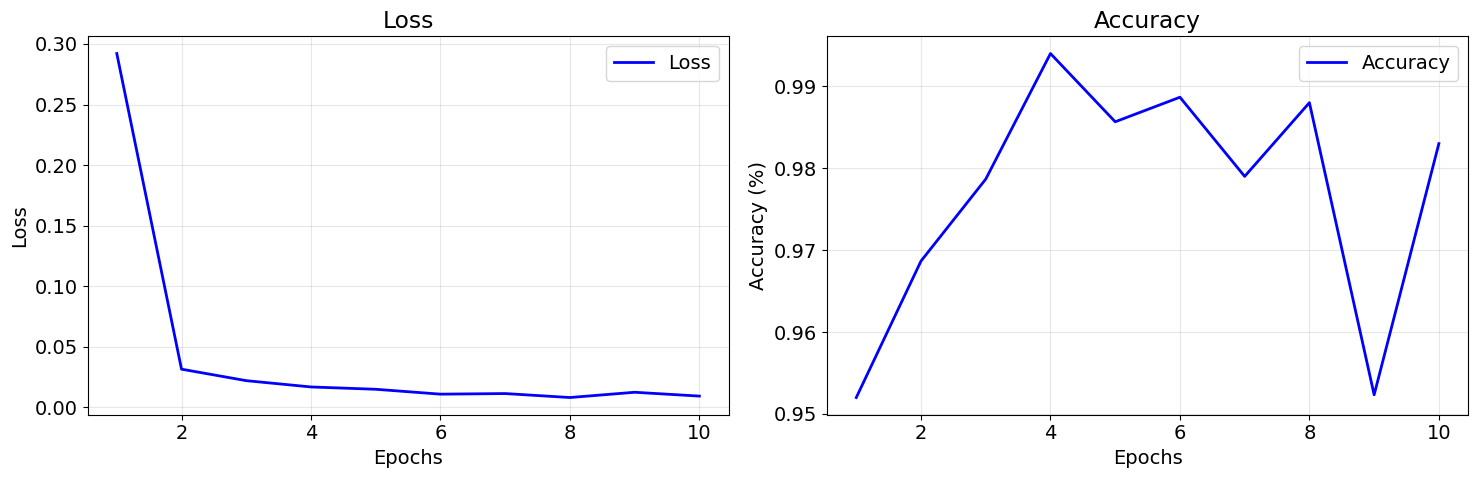

In [43]:
plot_metrics(losses, accuracy_valid)
clear_output(wait=True)

## InfoNCE

Обучим модель Multi-Format Contrastive Learning of Audio Representations до достижения сходимости.

Построим графики loss и accuracy, чтобы убедиться в стабилизации процесса обучения.

In [44]:
hyperparameters['MODEL_TITLE'] = 'InfoNCE'
hyperparameters['EPOCHS'] = 30
hyperparameters['MODE'] = 'All'
hyperparameters['LOSE'] = 'ContrastiveLoss'

config = DictConfig(hyperparameters)

#make the model, data and optimization problem
model, loss, optimizer, mel_transform = create(config)

#train the model
losses, accuracy_valid, accuracy_test = train(
    model,
    eval_head,
    loss,
    optimizer,
    train_loader,
    val_loader,
    test_loader,
    config,
    mel_transform, None
)

  0%|          | 0/188 [00:00<?, ?step/s]

  0%|          | 0/188 [00:00<?, ?step/s]

  0%|          | 0/24 [00:00<?, ?step/s]

Accuracy on validation: 0.5823333333333334


  0%|          | 0/24 [00:00<?, ?step/s]

...

  0%|          | 0/188 [00:00<?, ?step/s]

  0%|          | 0/188 [00:00<?, ?step/s]

  0%|          | 0/24 [00:00<?, ?step/s]

Accuracy on validation: 0.7056666666666667


  0%|          | 0/24 [00:00<?, ?step/s]

In [45]:
new_row = {'Method': 'InfoNCE', 'accuracy_valid': accuracy_valid, 'accuracy_test': accuracy_test}
final_metrics.loc[len(final_metrics)] = new_row

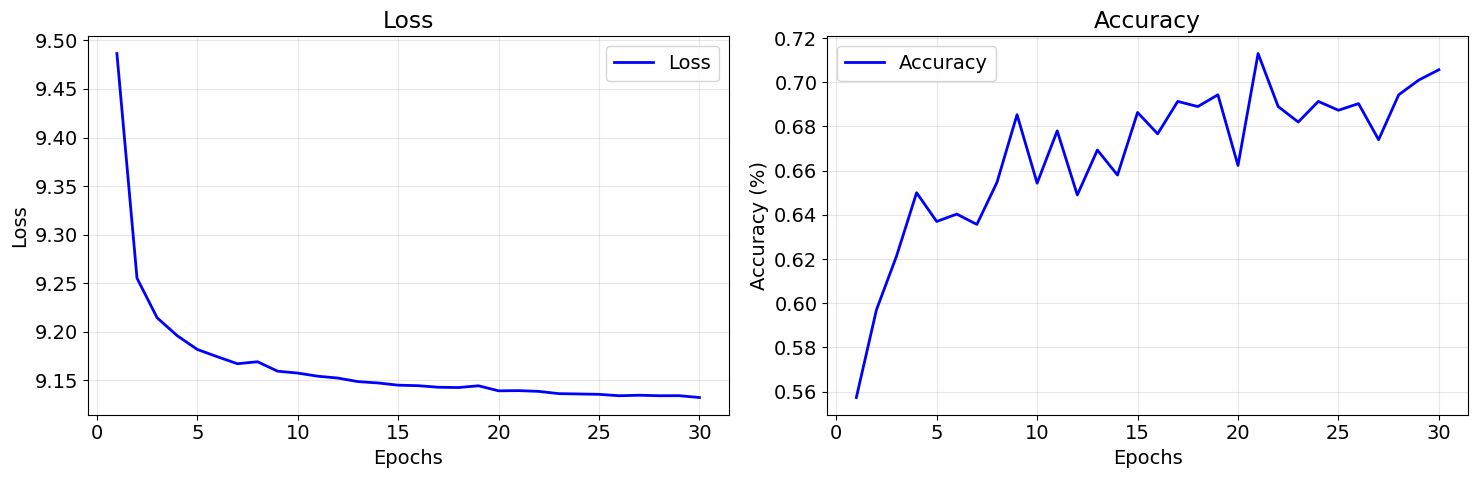

In [46]:
plot_metrics(losses, accuracy_valid)
clear_output(wait=True)

In [49]:
final_metrics.to_csv('final_metrics.csv', index=False)

## NCL

Заменим InfoNCE loss в Multi-Format Contrastive Learning of Audio Representations Non-Contrastive Learning методом.
Обучим модель до сходимости, затем построем графики loss и accuracy, чтобы убедиться, что обучение стабилизировалось.

Рассмотрим некоторые из них:
- BYOL([paper](https://arxiv.org/pdf/2006.07733))
- SimSiam([paper](https://arxiv.org/pdf/2011.10566))
- Barlow Twins([paper](https://arxiv.org/pdf/2103.03230))
- VicReg([paper](https://arxiv.org/pdf/2105.04906))

Но, остановимся на VicReg, как более свежем и более подходящем нам по использованию памяти и архитектуры проекта.

In [50]:
hyperparameters['MODEL_TITLE'] = 'NCL'
hyperparameters['LOSE'] = 'VicReg'

config = DictConfig(hyperparameters)

model, loss, optimizer, mel_transform = create(config)

losses, accuracy_valid, accuracy_test = train(
    model,
    eval_head,
    loss,
    optimizer,
    train_loader,
    val_loader,
    test_loader,
    config,
    mel_transform, None
)

  0%|          | 0/188 [00:00<?, ?step/s]

  0%|          | 0/188 [00:00<?, ?step/s]

  0%|          | 0/24 [00:00<?, ?step/s]

Accuracy on validation: 0.48433333333333334


  0%|          | 0/24 [00:00<?, ?step/s]

...

  0%|          | 0/188 [00:00<?, ?step/s]

  0%|          | 0/188 [00:00<?, ?step/s]

  0%|          | 0/24 [00:00<?, ?step/s]

Accuracy on validation: 0.6806666666666666


  0%|          | 0/24 [00:00<?, ?step/s]

In [64]:
final_metrics = pd.read_csv('final_metrics.csv')

In [65]:
new_row = {'Method': 'NCL', 'accuracy_valid': accuracy_valid, 'accuracy_test': accuracy_test}
final_metrics.loc[len(final_metrics)] = new_row

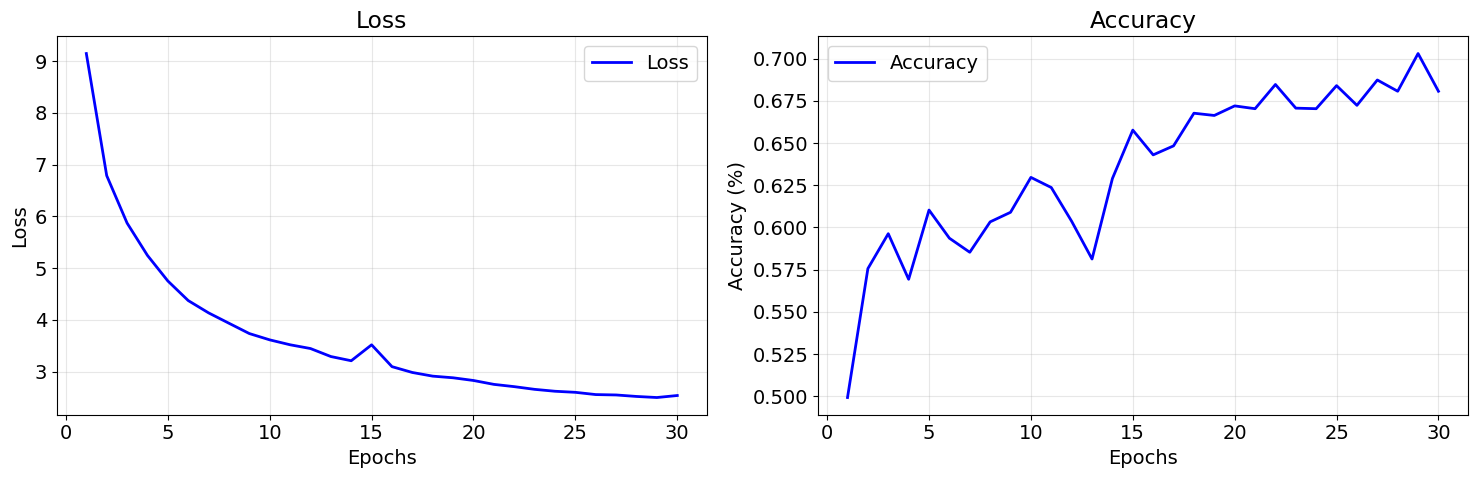

In [66]:
plot_metrics(losses, accuracy_valid)
clear_output(wait=True)

In [67]:
final_metrics.to_csv('final_metrics.csv', index=False)

## Валидация

Сравним полученные результаты на тестовом множестве и построим графики accuracy для разных подходов

1. Supervised training

2. InfoNCE (contrastive learning)

3. Non-Contrastive Learning (NCL)

### Выше я уже писал, что я ленивый и сделал сразу прогон и для тестовых данных, конечно же не считая по нему лосса, поэтому просто посмотрим на полученные результаты:)

In [68]:
final_metrics = pd.read_csv('final_metrics.csv')

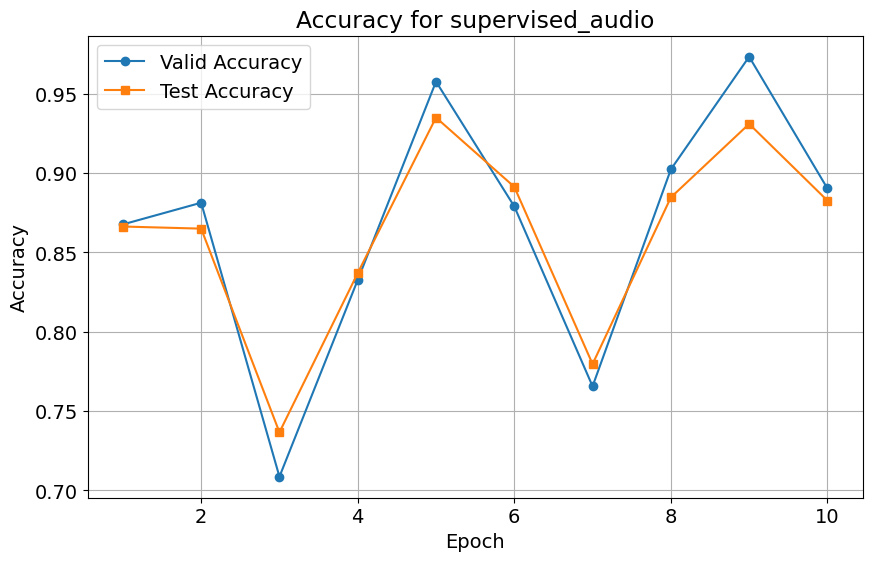

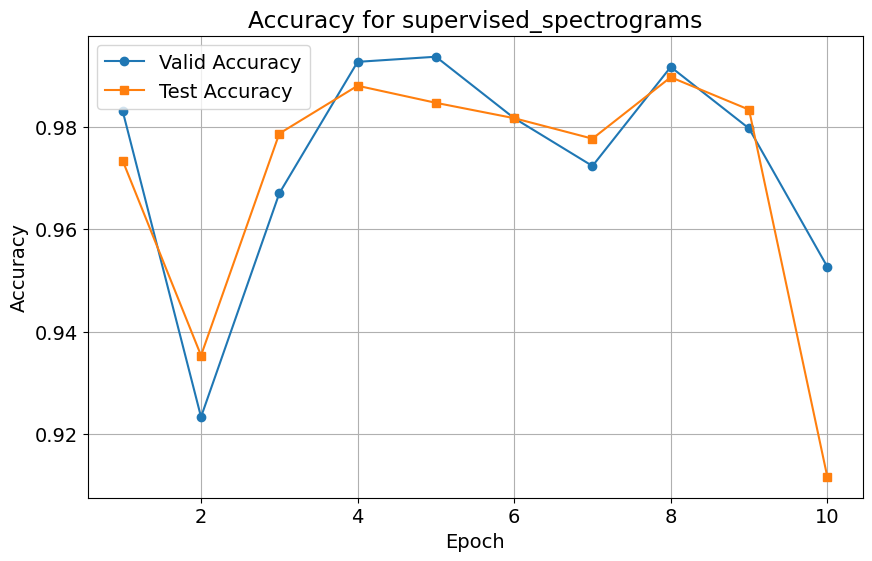

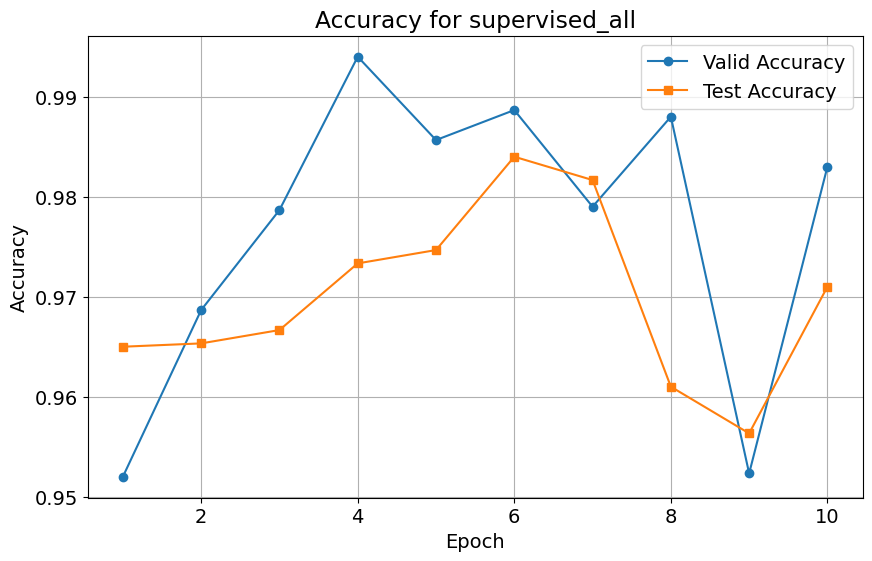

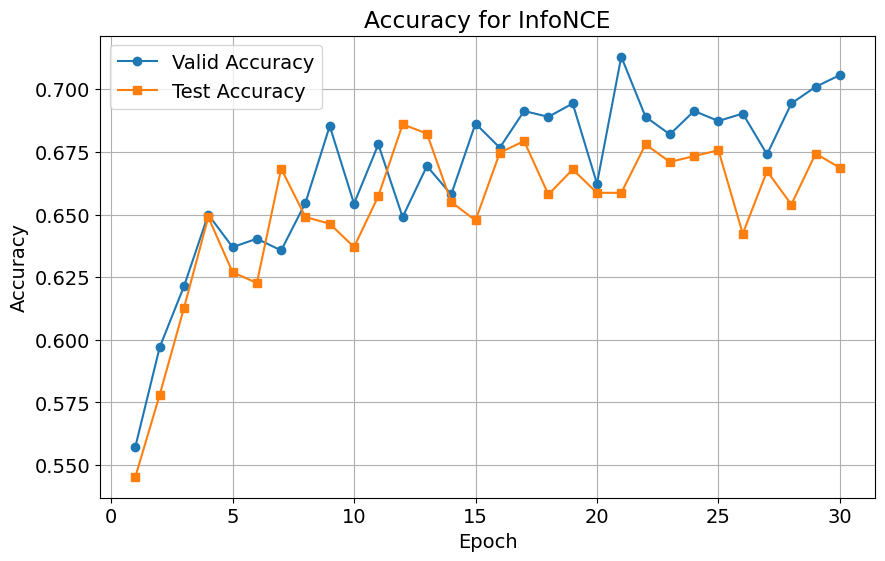

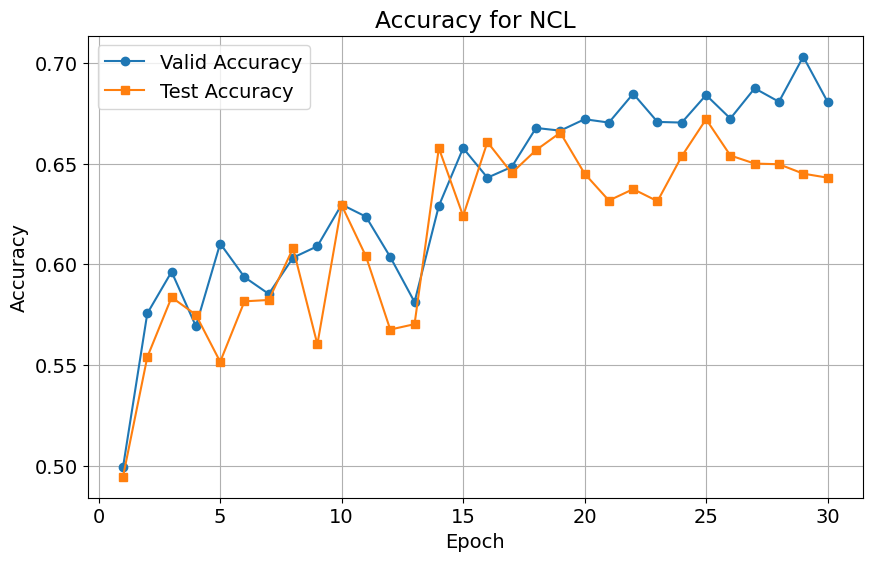

In [70]:
final_metrics['accuracy_valid'] = final_metrics['accuracy_valid'].apply(ast.literal_eval)
final_metrics['accuracy_test'] = final_metrics['accuracy_test'].apply(ast.literal_eval)

for i in range(len(final_metrics)):
    method_name = final_metrics['Method'][i]
    
    # Получаем значения точности
    valid_acc = final_metrics['accuracy_valid'][i]
    test_acc = final_metrics['accuracy_test'][i]
    
    # Определяем количество измерений
    x = list(range(1, len(valid_acc)+1))
    
    # Строим график
    plt.figure(figsize=(10, 6))  # размер графика
    plt.plot(x, valid_acc, marker='o', label="Valid Accuracy")
    plt.plot(x, test_acc, marker='s', label="Test Accuracy")
    
    # Подписываем оси и добавляем заголовок
    plt.title(f'Accuracy for {method_name}')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

По графикам видно, что при обучении с учителем модель обучается достаточно быстро, но при обучении просто на аудиосигнале еще и процесс обучения происходит с огромным скачками в метрике.

При рбечении только на спектрограммах процесс выглядит чуть лучше, но при обучении на обоих сигналах, аудио вносит свой хаос в процесс обучения.

При контрактивном обучении наблюдаем постепенное обучении и оно уже менее скачкообразно.

При лоссе VicReg наблюдается постепеный рост метрики без переобучения, и при 25 эпохах имеем некое снижение метрики на тесте.

Для прогона на 10 эпохах обучение с учителем кажется предпочтительней, но, если смотреть глубже, то при дороговизне разметки либо при огромном числе данных, обучение без учителя уже становится предпочтительным.

Предположительно, если усложнить сеть и пообучать больше эпох, возможен выход на уровень метрик облучения с учителем, но это уже отдельная история и потенциал для дальнейших исследований.